# Dynamic Delta Hedging

This notebook studies discrete dynamic Delta hedging for a European call
option under the Black–Scholes model.

A replicating portfolio consists of:

- $\Delta_t$ units of the underlying asset;
- a cash position $B_t$ earning the risk-free rate.

Its value is

$$
\Pi_t = \Delta_t S_t + B_t.
$$

For a European call, the Black–Scholes hedge ratio is

$$
\Delta_t = N(d_1).
$$

At inception, the cash position is

$$
B_0 = C_0 - \Delta_0 S_0,
$$

so the initial portfolio value equals the option price $C_0$.

In continuous time, under the Black–Scholes assumptions, continuous
rebalancing replicates the option payoff. In practice, rebalancing is
discrete, producing a hedging error:

$$
\text{Hedging Error}
=
\Pi_T - \max(S_T-K,0).
$$

This notebook investigates how the hedging error changes with the
rebalancing frequency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def calculate_d1(S, K, r, sigma, tau):
    """Calculate d1 in the Black-Scholes model."""
    return (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))


def black_scholes_call_price(S, K, r, sigma, tau):
    """Calculate the Black-Scholes price of a European call."""
    d1 = calculate_d1(S, K, r, sigma, tau)
    d2 = d1 - sigma * np.sqrt(tau)

    return (
        S * norm.cdf(d1)
        - K * np.exp(-r * tau) * norm.cdf(d2)
    )


def call_delta(S, K, r, sigma, tau):
    """Calculate the Delta of a European call."""
    d1 = calculate_d1(S, K, r, sigma, tau)
    return norm.cdf(d1)

In [3]:
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

call_price = black_scholes_call_price(
    S=S0,
    K=K,
    r=r,
    sigma=sigma,
    tau=T
)

initial_delta = call_delta(
    S=S0,
    K=K,
    r=r,
    sigma=sigma,
    tau=T
)

initial_cash = call_price - initial_delta * S0

print(f"Call price:    {call_price:.4f}")
print(f"Initial Delta: {initial_delta:.4f}")
print(f"Stock value:   {initial_delta * S0:.4f}")
print(f"Cash position: {initial_cash:.4f}")
print(
    f"Portfolio value: "
    f"{initial_delta * S0 + initial_cash:.4f}"
)

Call price:    10.4506
Initial Delta: 0.6368
Stock value:   63.6831
Cash position: -53.2325
Portfolio value: 10.4506


## Simulating One Price Path

Under the risk-neutral measure, the underlying asset follows

$$
dS_t=rS_t\,dt+\sigma S_t\,dW_t.
$$

Over a discrete time interval $\Delta t$, the exact update is

$$
S_{t+\Delta t}
=
S_t\exp\left[
\left(r-\frac{1}{2}\sigma^2\right)\Delta t
+\sigma\sqrt{\Delta t}Z
\right],
$$

where $Z\sim N(0,1)$.

The path is simulated under the risk-neutral measure because the
Black–Scholes replicating portfolio is constructed consistently with
risk-neutral option pricing.

In [4]:
def simulate_gbm_path(S0, r, sigma, T, steps, seed=None):
    """Simulate one risk-neutral geometric Brownian motion path."""
    rng = np.random.default_rng(seed)

    dt = T / steps
    random_shocks = rng.standard_normal(steps)

    log_returns = (
        (r - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * random_shocks
    )

    prices = np.empty(steps + 1)
    prices[0] = S0
    prices[1:] = S0 * np.exp(np.cumsum(log_returns))

    times = np.linspace(0, T, steps + 1)

    return times, prices

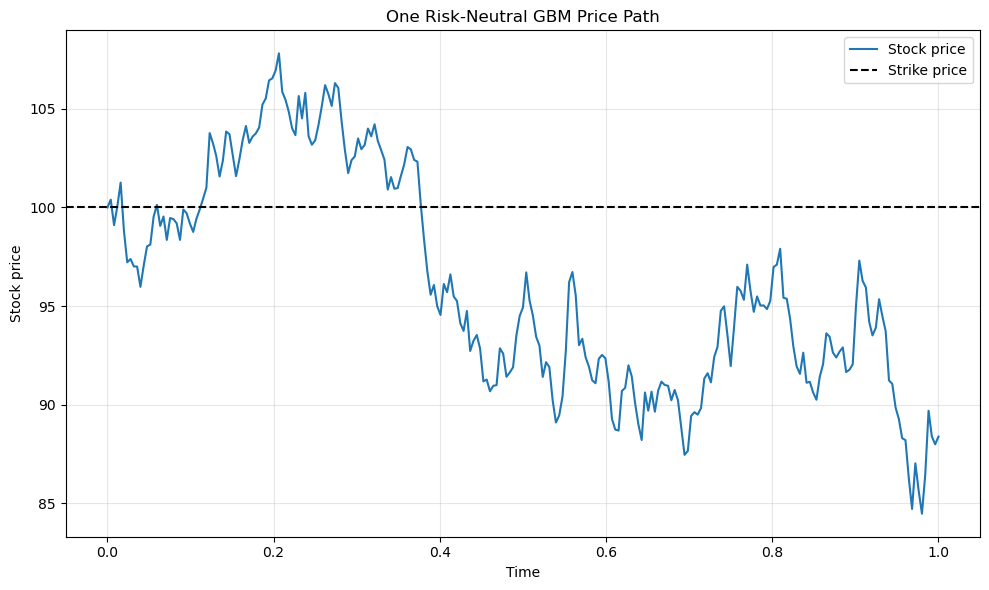

Initial stock price: 100.0000
Terminal stock price: 88.3759


In [5]:
steps = 252

times, stock_path = simulate_gbm_path(
    S0=S0,
    r=r,
    sigma=sigma,
    T=T,
    steps=steps,
    seed=42
)

plt.figure(figsize=(10, 6))
plt.plot(times, stock_path, label="Stock price")
plt.axhline(
    K,
    color="black",
    linestyle="--",
    label="Strike price"
)
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.title("One Risk-Neutral GBM Price Path")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial stock price: {stock_path[0]:.4f}")
print(f"Terminal stock price: {stock_path[-1]:.4f}")

## Discrete Delta Hedging

At inception, the replicating portfolio is initialised with the
Black–Scholes option value:

$$
\Pi_0=C_0=\Delta_0S_0+B_0.
$$

Between two rebalancing times, the cash position earns the risk-free
rate:

$$
B_{t+\Delta t}^{\text{before}}
=
B_t e^{r\Delta t}.
$$

At the next rebalancing time, Delta changes from $\Delta_t$ to
$\Delta_{t+\Delta t}$. The required stock transaction is

$$
\left(\Delta_{t+\Delta t}-\Delta_t\right)S_{t+\Delta t}.
$$

The cash position after rebalancing is therefore

$$
B_{t+\Delta t}
=
B_{t+\Delta t}^{\text{before}}
-
\left(\Delta_{t+\Delta t}-\Delta_t\right)S_{t+\Delta t}.
$$

No additional capital is added to or withdrawn from the portfolio.
This is called a self-financing strategy.

At maturity, the hedging error is

$$
\text{Hedging Error}
=
\Pi_T-\max(S_T-K,0).
$$

In [6]:
def delta_hedge_path(
    times,
    stock_path,
    K,
    r,
    sigma,
    T
):
    """Apply discrete Delta hedging to one simulated stock path."""
    steps = len(times) - 1
    dt = T / steps

    initial_price = black_scholes_call_price(
        S=stock_path[0],
        K=K,
        r=r,
        sigma=sigma,
        tau=T
    )

    delta = call_delta(
        S=stock_path[0],
        K=K,
        r=r,
        sigma=sigma,
        tau=T
    )

    cash = initial_price - delta * stock_path[0]

    records = [{
        "Time": times[0],
        "StockPrice": stock_path[0],
        "Delta": delta,
        "Cash": cash,
        "PortfolioValue": delta * stock_path[0] + cash,
        "OptionValue": initial_price
    }]

    for step in range(1, steps):
        cash *= np.exp(r * dt)

        tau = T - times[step]

        new_delta = call_delta(
            S=stock_path[step],
            K=K,
            r=r,
            sigma=sigma,
            tau=tau
        )

        stock_trade = (
            new_delta - delta
        ) * stock_path[step]

        cash -= stock_trade
        delta = new_delta

        option_value = black_scholes_call_price(
            S=stock_path[step],
            K=K,
            r=r,
            sigma=sigma,
            tau=tau
        )

        records.append({
            "Time": times[step],
            "StockPrice": stock_path[step],
            "Delta": delta,
            "Cash": cash,
            "PortfolioValue": delta * stock_path[step] + cash,
            "OptionValue": option_value
        })

    cash *= np.exp(r * dt)

    terminal_stock_price = stock_path[-1]
    terminal_portfolio = delta * terminal_stock_price + cash
    option_payoff = max(terminal_stock_price - K, 0.0)
    hedging_error = terminal_portfolio - option_payoff

    records.append({
        "Time": times[-1],
        "StockPrice": terminal_stock_price,
        "Delta": delta,
        "Cash": cash,
        "PortfolioValue": terminal_portfolio,
        "OptionValue": option_payoff
    })

    history = pd.DataFrame(records)

    return history, hedging_error

In [7]:
hedge_history, hedging_error = delta_hedge_path(
    times=times,
    stock_path=stock_path,
    K=K,
    r=r,
    sigma=sigma,
    T=T
)

terminal_portfolio = hedge_history["PortfolioValue"].iloc[-1]
terminal_payoff = max(stock_path[-1] - K, 0.0)

print(f"Terminal stock price: {stock_path[-1]:.4f}")
print(f"Option payoff:        {terminal_payoff:.4f}")
print(f"Portfolio value:      {terminal_portfolio:.4f}")
print(f"Hedging error:        {hedging_error:.4f}")

Terminal stock price: 88.3759
Option payoff:        0.0000
Portfolio value:      0.7109
Hedging error:        0.7109


In [8]:
display(hedge_history.head())
display(hedge_history.tail())

,Time,StockPrice,Delta,Cash,PortfolioValue,OptionValue
0,0.000000,100.000000,0.636831,-53.232482,10.450584,10.450584
1,0.003968,100.396597,0.643986,-53.961457,10.692585,10.679049
2,0.007937,99.101521,0.619170,-51.512806,9.847867,9.835571
3,0.011905,100.054860,0.637082,-53.315197,10.427923,10.408998
4,0.015873,101.259617,0.659208,-55.566229,11.184873,11.164193


,Time,StockPrice,Delta,Cash,PortfolioValue,OptionValue
248,0.984127,86.454622,4.955034e-09,0.710314,0.710315,1.775617e-09
249,0.988095,89.688193,3.728305e-07,0.710422,0.710456,1.367703e-07
250,0.992063,88.384607,2.624240e-12,0.710596,0.710596,5.747673e-13
251,0.996032,87.985970,1.891442e-24,0.710737,0.710737,2.027472e-25
252,1.000000,88.375927,1.891442e-24,0.710878,0.710878,0.000000e+00


## Hedging Dynamics Along One Path

The replicating portfolio is compared with the Black–Scholes option
value throughout the simulated path.

With discrete rebalancing, the two values remain close but do not match
perfectly. Delta is recalculated as the stock price and remaining time
change.

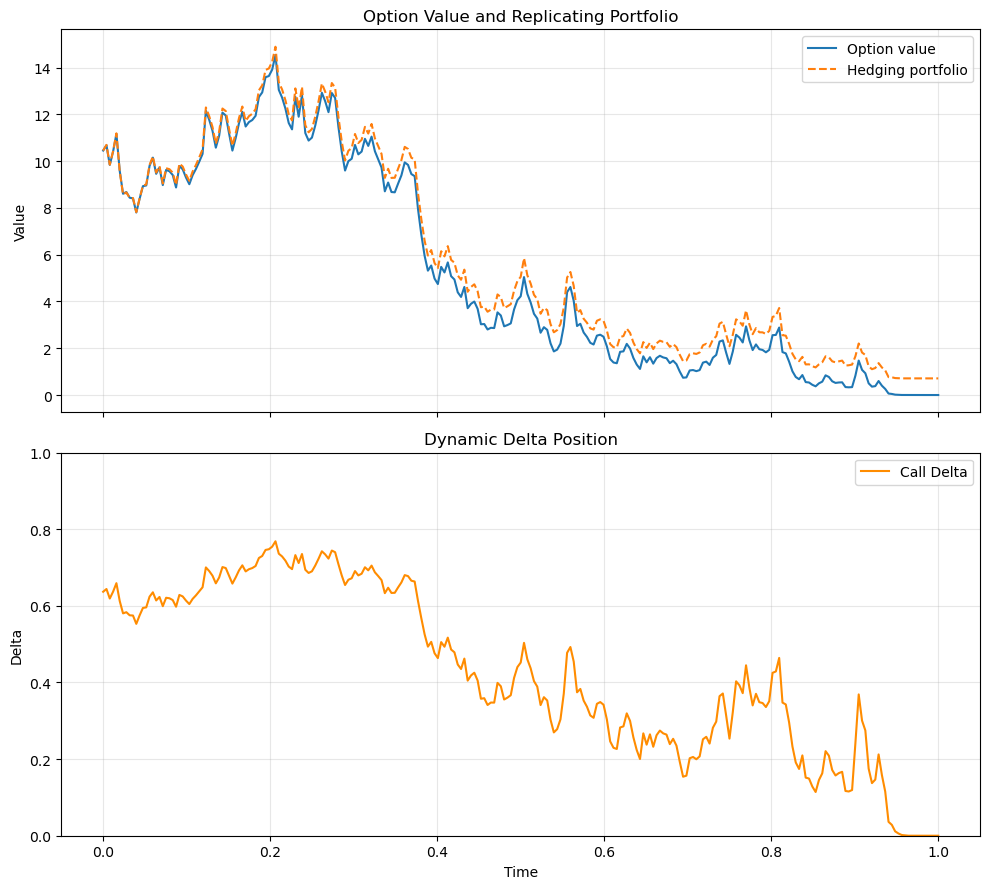

In [9]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True
)

axes[0].plot(
    hedge_history["Time"],
    hedge_history["OptionValue"],
    label="Option value"
)

axes[0].plot(
    hedge_history["Time"],
    hedge_history["PortfolioValue"],
    label="Hedging portfolio",
    linestyle="--"
)

axes[0].set_ylabel("Value")
axes[0].set_title(
    "Option Value and Replicating Portfolio"
)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    hedge_history["Time"],
    hedge_history["Delta"],
    color="darkorange",
    label="Call Delta"
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Delta")
axes[1].set_title("Dynamic Delta Position")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Hedging Error Across Many Paths

A single simulated path does not reveal the overall performance of the
hedging strategy. We therefore simulate many independent price paths
and calculate the terminal hedging error for each path.

The experiment compares different rebalancing frequencies. Under the
Black–Scholes assumptions, more frequent rebalancing should reduce the
dispersion of the hedging errors.

In [10]:
def simulate_hedging_errors(
    S0,
    K,
    r,
    sigma,
    T,
    steps,
    simulations,
    seed=None
):
    """Simulate hedging errors across many price paths."""
    rng = np.random.default_rng(seed)

    dt = T / steps

    stock_prices = np.full(
        simulations,
        S0,
        dtype=float
    )

    initial_price = black_scholes_call_price(
        S=S0,
        K=K,
        r=r,
        sigma=sigma,
        tau=T
    )

    delta = np.full(
        simulations,
        call_delta(S0, K, r, sigma, T),
        dtype=float
    )

    cash = initial_price - delta * S0

    for step in range(1, steps + 1):
        random_shocks = rng.standard_normal(simulations)

        stock_prices *= np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * random_shocks
        )

        cash *= np.exp(r * dt)

        if step < steps:
            tau = T - step * dt

            new_delta = call_delta(
                S=stock_prices,
                K=K,
                r=r,
                sigma=sigma,
                tau=tau
            )

            cash -= (
                new_delta - delta
            ) * stock_prices

            delta = new_delta

    terminal_portfolio = delta * stock_prices + cash
    option_payoffs = np.maximum(stock_prices - K, 0.0)

    hedging_errors = (
        terminal_portfolio - option_payoffs
    )

    return hedging_errors

In [11]:
rebalancing_frequencies = {
    "Monthly": 12,
    "Weekly": 52,
    "Daily": 252
}

simulations = 10000
error_samples = {}
summary_rows = []

for frequency, steps in rebalancing_frequencies.items():
    errors = simulate_hedging_errors(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        steps=steps,
        simulations=simulations,
        seed=42 + steps
    )

    error_samples[frequency] = errors

    summary_rows.append({
        "Frequency": frequency,
        "Rebalancings": steps,
        "MeanError": np.mean(errors),
        "StandardDeviation": np.std(
            errors,
            ddof=1
        ),
        "MeanAbsoluteError": np.mean(
            np.abs(errors)
        ),
        "RootMeanSquaredError": np.sqrt(
            np.mean(errors**2)
        )
    })

error_summary = pd.DataFrame(summary_rows)
error_summary

,Frequency,Rebalancings,MeanError,StandardDeviation,MeanAbsoluteError,RootMeanSquaredError
0,Monthly,12,-0.012645,1.945562,1.468831,1.945506
1,Weekly,52,-0.007003,0.958170,0.716946,0.958148
2,Daily,252,-0.003095,0.435153,0.323152,0.435143


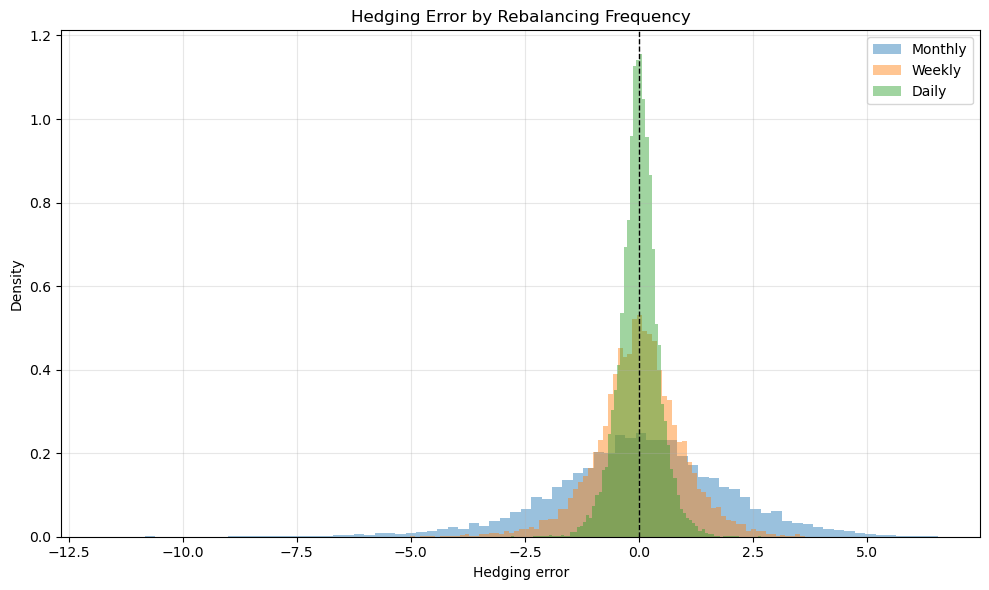

In [12]:
plt.figure(figsize=(10, 6))

for frequency, errors in error_samples.items():
    plt.hist(
        errors,
        bins=80,
        density=True,
        alpha=0.45,
        label=frequency
    )

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Hedging error")
plt.ylabel("Density")
plt.title(
    "Hedging Error by Rebalancing Frequency"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

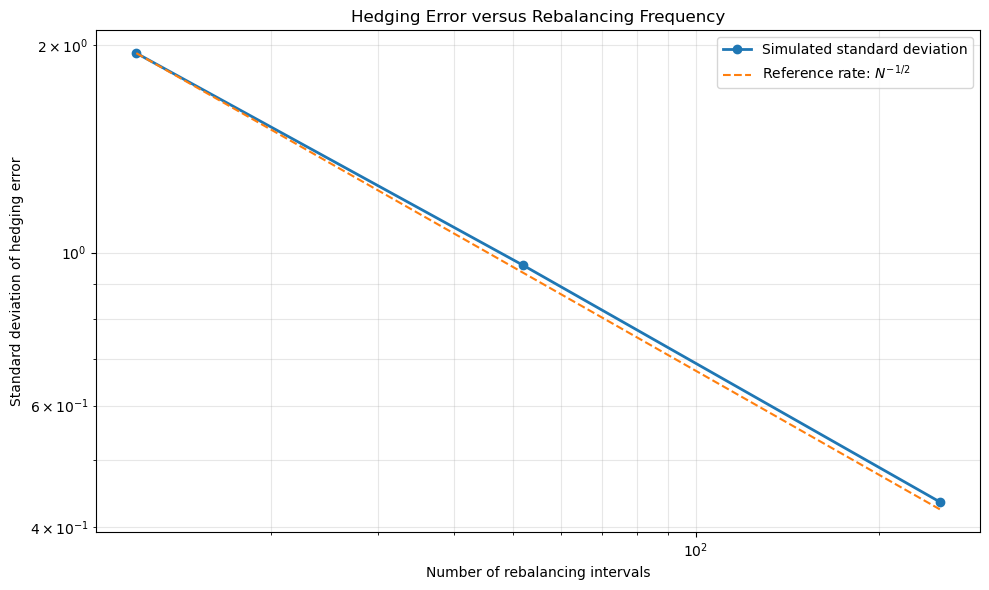

In [13]:
rebalancing_counts = error_summary[
    "Rebalancings"
].to_numpy()

error_standard_deviations = error_summary[
    "StandardDeviation"
].to_numpy()

reference_curve = (
    error_standard_deviations[0]
    * np.sqrt(
        rebalancing_counts[0]
        / rebalancing_counts
    )
)

plt.figure(figsize=(10, 6))

plt.loglog(
    rebalancing_counts,
    error_standard_deviations,
    marker="o",
    linewidth=2,
    label="Simulated standard deviation"
)

plt.loglog(
    rebalancing_counts,
    reference_curve,
    linestyle="--",
    label=r"Reference rate: $N^{-1/2}$"
)

plt.xlabel("Number of rebalancing intervals")
plt.ylabel("Standard deviation of hedging error")
plt.title(
    "Hedging Error versus Rebalancing Frequency"
)
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Conclusion

This notebook implemented discrete dynamic Delta hedging for a European
call option under the Black–Scholes model.

For one simulated path, the replicating portfolio tracked the
Black–Scholes option value closely, although discrete rebalancing
produced a non-zero terminal hedging error.

Across 10,000 simulated paths:

- monthly rebalancing produced a hedging-error standard deviation of approximately $1.946$;
- weekly rebalancing reduced it to approximately $0.958$;
- daily rebalancing reduced it further to approximately $0.435$.

The mean hedging error remained close to zero at all three frequencies,
while the standard deviation, mean absolute error and root mean squared
error decreased as rebalancing became more frequent.

The results were consistent with an approximate $N^{-1/2}$ convergence
rate, where $N$ is the number of rebalancing intervals.

The model assumes constant volatility, continuous trading, no
transaction costs and no price jumps. In practice, more frequent
rebalancing reduces discretisation error but may increase transaction
costs.